In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import os
from google.colab import drive

df1_path = "/content/drive/MyDrive/FYP/Suicide_Detection.csv"
df2_path = "/content/drive/MyDrive/FYP/suicide_only_clean.csv"

def load_and_standardize_data(path1, path2):
    if not os.path.exists(path1) or not os.path.exists(path2):
        print(f"Error: One or both files not found.\nPath 1: {path1}\nPath 2: {path2}")
        return None

    print("Loading Suicide_Detection.csv (DF1)...")
    df1 = pd.read_csv(path1)
    df1 = df1.rename(columns={'class': 'label'})
    df1['label'] = df1['label'].map({'suicide': 1, 'non-suicide': 0})
    df1 = df1[['text', 'label']]

    print("Loading suicide_only_clean.csv (DF2)...")
    df2 = pd.read_csv(path2)
    df2 = df2[['text']]
    df2['label'] = 1 

    df = pd.concat([df1, df2], ignore_index=True)
    df = df.dropna(subset=['text', 'label'])
    return df

df = load_and_standardize_data(df1_path, df2_path)
if df is not None:
    print(f"Total samples: {len(df)}")
    print(f"Class distribution:\n{df['label'].value_counts()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Suicide_Detection.csv (DF1)...
Loading suicide_only_clean.csv (DF2)...
Total samples: 242066
Class distribution:
label
1    126029
0    116037
Name: count, dtype: int64


Preprocessing text...
Building CNN model...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training model...
Epoch 1/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.9224 - loss: 0.2031 - val_accuracy: 0.9442 - val_loss: 0.1498
Epoch 2/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9517 - loss: 0.1333 - val_accuracy: 0.9440 - val_loss: 0.1487
Epoch 3/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9636 - loss: 0.1013 - val_accuracy: 0.9448 - val_loss: 0.1650
Epoch 4/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9724 - loss: 0.0765 - val_accuracy: 0.9405 - val_loss: 0.1795
Epoch 5/10
2724/2724 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9784 - loss: 0.0587 - val_accuracy: 0.9415 - val_loss: 0.1980
Evaluating model...
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

Classification Report:
              precision    recall  f1-score   support

 Non-Suicide       0.94      0.95      0.94     23208
     Suicide       0.95      0.94      0.95     25206

    accuracy                           0.95     48414
   macro avg       0.9

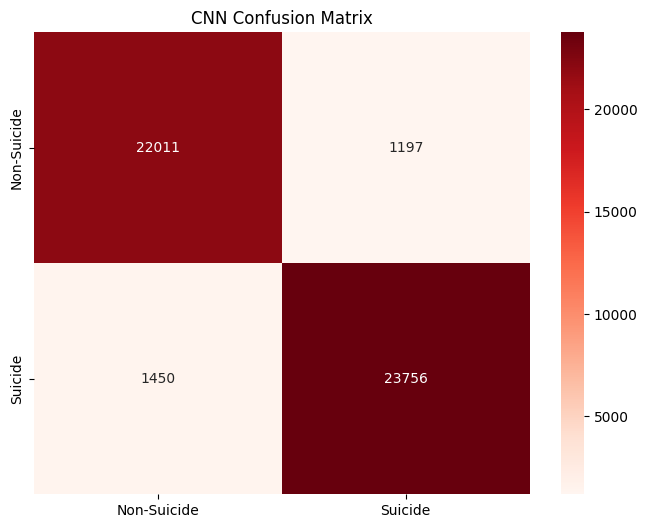

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

# 1. Text Cleaning
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'\@\w+|\#','', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Preprocessing text...")
df['clean_text'] = df['text'].apply(clean_text)

max_words = 20000
max_len = 250

tokenizer = Tokenizer(num_words=max_words, lower=True)
tokenizer.fit_on_texts(df['clean_text'])
sequences = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(sequences, maxlen=max_len)
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Building CNN model...")
model = Sequential([
    Embedding(max_words, 128),
    SpatialDropout1D(0.3),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

print("Training model...")
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("Evaluating model...")
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Suicide', 'Suicide']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Non-Suicide', 'Suicide'], yticklabels=['Non-Suicide', 'Suicide'])
plt.title('CNN Confusion Matrix')
plt.show()

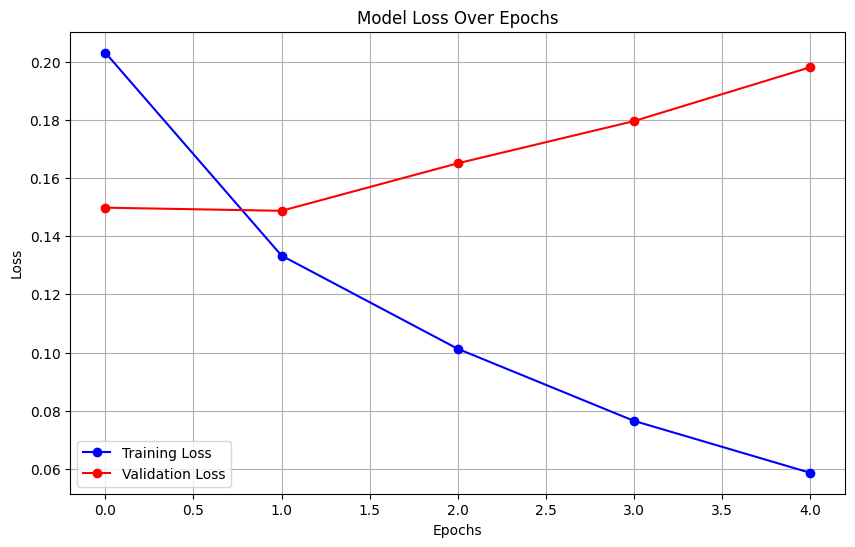

In [7]:
def plot_loss(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='blue', marker='o')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='red', marker='o')
    plt.title('Model Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

if 'history' in locals():
    plot_loss(history)
else:
    print("Error: 'history' object not found. Please train the model first.")